<a href="https://colab.research.google.com/github/alitourani/vision-paper-hub/blob/main/categories/ocr/tesseract/tesseract-ocr.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **👁️‍🗨️ Vision Paper Hub** / **OCR** / **Tesseract OCR**

This colaboratory is made to assess the quality of Tesseract OCR library.

- 🚀 [Benchmark](https://github.com/alitourani/vision-paper-hub/tree/main/categories/ocr/tesseract)
- 🔗 [GitHub Repo](https://github.com/tesseract-ocr/tesseract)
- 📃 [Paper](https://doi.org/10.1109/DAS.2012.45)

## **I. Install the Repository**

Tesseract OCR is available in `pip` and you can easily install it as below:

In [3]:
!sudo apt install tesseract-ocr
!pip install pytesseract

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
tesseract-ocr is already the newest version (4.1.1-2.1build1).
0 upgraded, 0 newly installed, 0 to remove and 37 not upgraded.


## **II. Upload an Image Containing Text**

Use the below button to upload from you local disk ([Sample Image](https://i.etsystatic.com/46492439/r/il/637756/6264606106/il_794xN.6264606106_2x2l.jpg)).

Saving sample.jpg to sample (1).jpg
- File "sample (1).jpg" uploaded with length 349770 bytes.


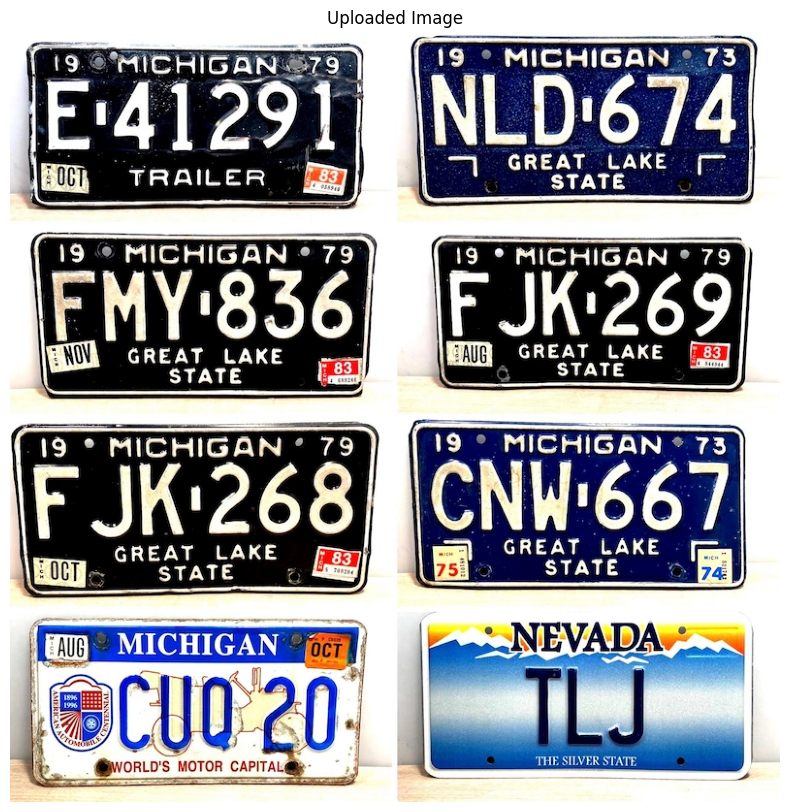

In [27]:
import os
import tempfile
import cv2 as cv
import numpy as np
import PIL.Image as Image
from google.colab import files
import matplotlib.pyplot as plt

# Variable for uploading files
image_path = ""
image_cv = None
image_pil = None
uploaded = files.upload()

for fn in uploaded.keys():
  print('- File "{name}" uploaded with length {length} bytes.'.format(
      name=fn, length=len(uploaded[fn])))

  # Save the uploaded file to a temporary location
  suffix = os.path.splitext(fn)[1] # Get extension
  with tempfile.NamedTemporaryFile(delete=False, suffix=suffix) as tmp_file:
    tmp_file.write(uploaded[fn])
    image_path = tmp_file.name

  try:
    # Load the image using OpenCV
    image_cv = cv.imread(image_path)
    # Load as PIL image
    image_pil = Image.fromarray(cv.cvtColor(image_cv, cv.COLOR_BGR2RGB))
  except Exception as X:
    print(f"[Error]: Could not load image '{fn}' with OpenCV!")

  # Display the image
  if image_pil is not None:
    plt.figure(figsize=(10, 10))
    plt.imshow(image_pil)
    plt.title(f"Uploaded Image")
    plt.axis('off')
    plt.show()

## **III. Apply Pre-Processing**

By applying pre-processing solutions, the parts of the image with text will be enhanced for OCR.

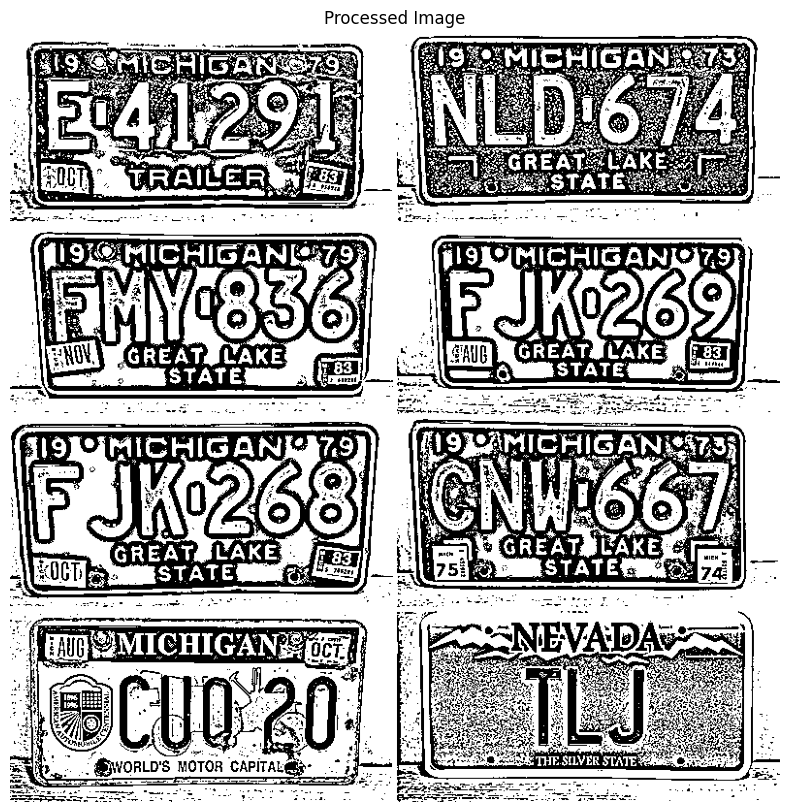

In [28]:
def applyPreprocessing(image_cv):
  # Convert to grayscale
  gray = cv.cvtColor(image_cv, cv.COLOR_BGR2GRAY)
  # Adaptive thresholding (better for varying lighting)
  thresh = cv.adaptiveThreshold(gray, 255, cv.ADAPTIVE_THRESH_GAUSSIAN_C,
                                cv.THRESH_BINARY, 11, 2)
  # Denoise the image
  denoised = cv.fastNlMeansDenoising(thresh, None, 10, 7, 21)
  # Dilation and erosion to remove noise
  kernel = np.ones((1, 1), np.uint8)
  processed = cv.dilate(denoised, kernel, iterations=1)
  processed = cv.erode(processed, kernel, iterations=1)
  # Return the processed image
  return processed

image_proc = applyPreprocessing(image_cv)

# Display the image
if image_pil is not None:
  plt.figure(figsize=(10, 10))
  plt.imshow(image_proc, cmap='gray')
  plt.title(f"Processed Image")
  plt.axis('off')
  plt.show()

## **IV. Read the Text using Tesseract**

**IV-A. Simple Solution**

In [36]:
import pytesseract

# You need to just pass the image path
text = pytesseract.image_to_string(Image.open(image_path))

print("Result:\n", text)

# Showing the bounding boxes
print(pytesseract.image_to_boxes(Image.open(image_path)))

Result:
 



**IV-B. Bypassing the Image Loader**

In [38]:
import pytesseract

# Here, you can have more configurations
text = pytesseract.image_to_string(image_proc, lang='eng',
                                        config='--psm 6',
                                        timeout=5)
print("Result:\n", text)

# Showing the bounding boxes
print(pytesseract.image_to_boxes(image_proc))

Result:
 (ENVY Ge WIMIMICHIG ANIA 9)
ficee Pinacs
ean LIT) J (
G ee 2 &
(ps og ee (Fa) SAB), GREATAUAKE 3) /
AST — i a
IMMICHIGAN (Qe SIea
Poon) lealinaan
“ASS CONAD | De el)
om, A Ls BE etre TRYTT re
AGT i SRS Fy iE any a
(ORME) | |AesNEVADAv=—
PclWeciime Jes
: Ria SOWIE uoTOs capirauege _” fos be Cs pee a

i 33 355 38 376 0
) 43 355 58 376 0
Y 77 365 87 375 0
W 83 273 135 389 0
o 133 275 199 376 0
n 203 277 276 389 0
“ 294 367 302 376 0
; 88 238 90 240 0
n 31 157 157 407 0
e 133 160 230 408 0
n 205 147 321 412 0
~ 94 98 95 117 0
W 109 30 116 42 0
O 117 30 126 42 0
R 124 51 132 53 0
L 128 30 138 55 0
D 137 31 153 42 0
' 154 38 156 42 0
S 154 22 161 59 0
M 173 31 182 42 0
O 184 31 192 43 0
T 189 49 197 53 0
O 193 31 201 42 0
R 201 31 219 56 0
‘ 227 29 228 48 0
C 227 29 231 48 0
A 227 31 236 43 0
P 237 31 246 48 0
I 246 31 253 42 0
T 254 31 265 42 0
A 266 31 274 42 0
L 268 29 283 48 0
@ 280 29 291 48 0
R 285 29 296 48 0
R 299 29 301 31 0
- 307 36 311 39 0
. 318 51 321 52 0
~ 0 0 794 79